# ABCs of Monte Carlo: inverse-transform sampling and the PIT

If $U \sim \text{Uniform}(0,1)$ and $F$ is a continuous CDF, then
$X = F^{-1}(U) \sim F.$
This is the **inverse-transform method**: push uniforms through the quantile function of any target $F$ to draw from $F$.

The reverse direction — apply $F$ to a sample from $F$ — gets you back to uniform:
$F(X) \sim \text{Uniform}(0,1).$
This is the **probability integral transform (PIT)**.

To make the equivalence concrete, we draw a single sample $\{u_t\}$ once and reuse it throughout: same uniforms ⇒ Normal draws ⇒ Exponential draws ⇒ uniforms again.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon

rng = np.random.default_rng(77)
n = 10_000

## Step 1 — Draw $\{u_t\} \sim \text{Uniform}(0,1)$

These uniforms will be reused for every step below.

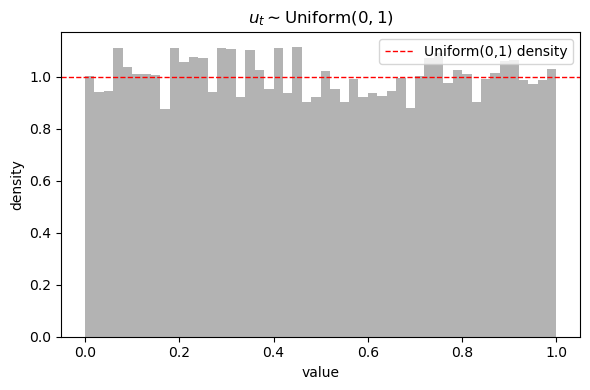

In [2]:
u = rng.uniform(size=n)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(u, bins=50, density=True, color="0.7")
ax.axhline(1.0, color="red", ls="--", lw=1, label="Uniform(0,1) density")
ax.set(title=r"$u_t \sim \mathrm{Uniform}(0,1)$", xlabel="value", ylabel="density")
ax.legend()
plt.tight_layout()
plt.show()

## Step 2 — Push the same $\{u_t\}$ through $\Phi^{-1}$ to get $\mathcal{N}(0,1)$

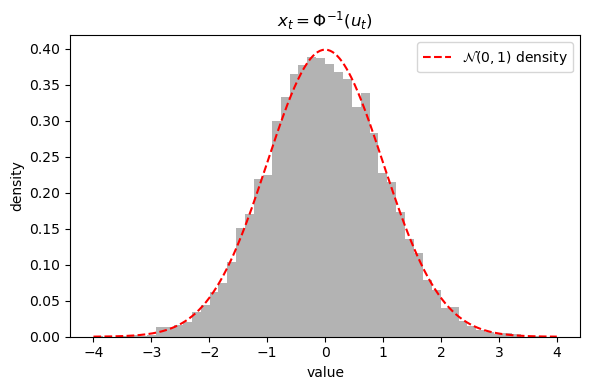

In [3]:
x_normal = norm.ppf(u)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(x_normal, bins=50, density=True, color="0.7")
xs = np.linspace(-4, 4, 400)
ax.plot(xs, norm.pdf(xs), color="red", ls="--", lw=1.5, label=r"$\mathcal{N}(0,1)$ density")
ax.set(title=r"$x_t = \Phi^{-1}(u_t)$", xlabel="value", ylabel="density")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 — Same $\{u_t\}$, push through $F^{-1}_{\text{Exp}}$ to get $\text{Exponential}(\text{mean}=10)$

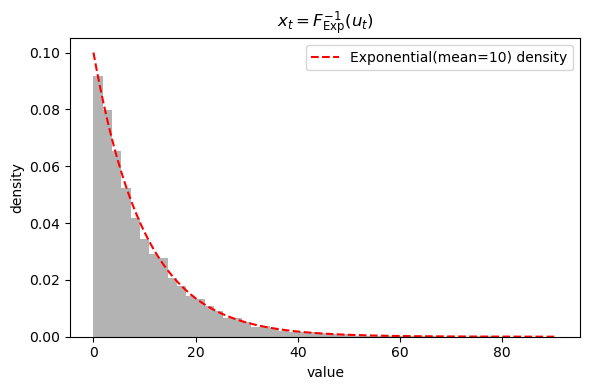

In [4]:
mean = 10
x_exp = expon.ppf(u, scale=mean)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(x_exp, bins=50, density=True, color="0.7")
xs = np.linspace(0, x_exp.max(), 400)
ax.plot(xs, expon.pdf(xs, scale=mean), color="red", ls="--", lw=1.5,
        label=f"Exponential(mean={mean}) density")
ax.set(title=r"$x_t = F_{\mathrm{Exp}}^{-1}(u_t)$", xlabel="value", ylabel="density")
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 — Close the loop with the PIT: apply $F_{\text{Exp}}$ back to recover Uniform$(0,1)$

By construction $F_{\text{Exp}}(x_t) = F_{\text{Exp}}(F_{\text{Exp}}^{-1}(u_t)) = u_t$, so the histogram should be flat at density 1.

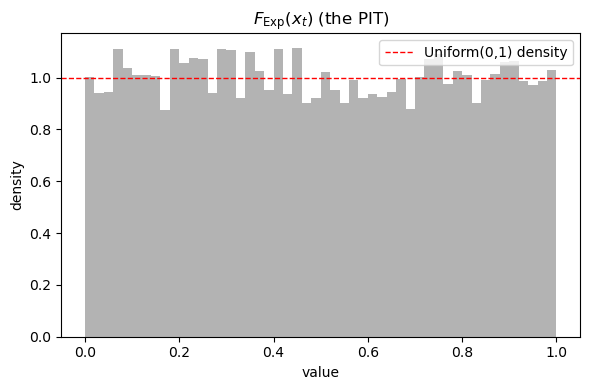

In [5]:
u_pit = expon.cdf(x_exp, scale=mean)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(u_pit, bins=50, density=True, color="0.7")
ax.axhline(1.0, color="red", ls="--", lw=1, label="Uniform(0,1) density")
ax.set(title=r"$F_{\mathrm{Exp}}(x_t)$ (the PIT)", xlabel="value", ylabel="density")
ax.legend()
plt.tight_layout()
plt.show()